In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [43]:
df=pd.DataFrame({
    "Age":[22, 25, 23, 24, 45, 47, 50, 48, 30, 32, 31, 29],
    "Income":[25000, 28000, 26000, 27000,75000, 80000, 85000, 78000,45000, 48000, 47000, 44000]
})
scaled=MinMaxScaler()
X_scaled=scaled.fit_transform(df)
print(X_scaled)

[[0.         0.        ]
 [0.10714286 0.05      ]
 [0.03571429 0.01666667]
 [0.07142857 0.03333333]
 [0.82142857 0.83333333]
 [0.89285714 0.91666667]
 [1.         1.        ]
 [0.92857143 0.88333333]
 [0.28571429 0.33333333]
 [0.35714286 0.38333333]
 [0.32142857 0.36666667]
 [0.25       0.31666667]]


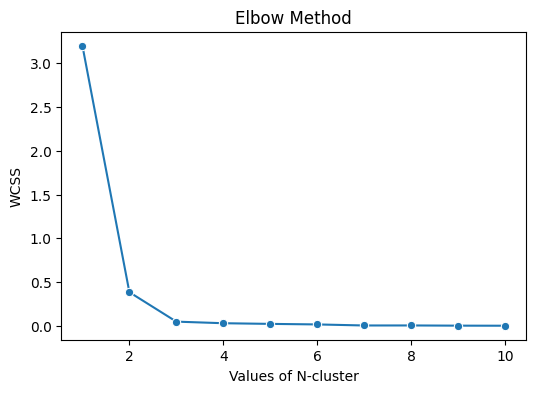

In [44]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
sns.lineplot(x=range(1,11),y=wcss,marker="o")
plt.xlabel("Values of N-cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

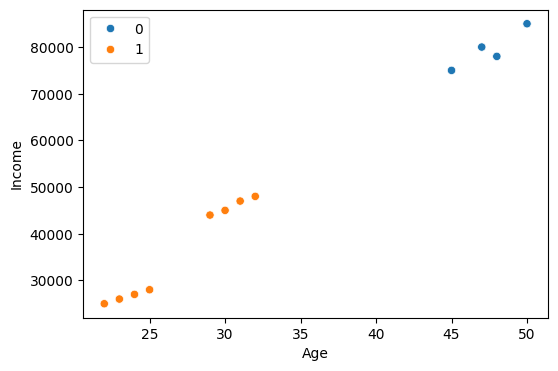

In [45]:
optimum_n=2
kmeans=KMeans(n_clusters=optimum_n,random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df["cluster"]=cluster
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x=df["Age"],y=df["Income"],hue=cluster)
plt.show()
